# 01 · The elastic dislocation forward model

This chapter connects slip on a buried rectangular fault to motion at Earth's
surface. We will build the physical picture gradually, look just far enough
inside the Okada solution to understand where it comes from, and then calculate
a complete synthetic earthquake with GeoDef.

**Learning objectives**

By the end of the chapter, you will be able to:

- describe the assumptions behind an elastic half-space fault model
- explain how a point-dislocation response is integrated across a rectangle
- identify strike, dip, length, width, depth, and slip in a 3-D fault view
- calculate seismic moment and moment magnitude from a slip model
- predict East, North, and Up surface displacement with GeoDef
- interpret component maps, profiles, and a GNSS vector map
- explain why fixed-geometry displacement is linear in slip

**Prerequisites:** Chapter 00 or equivalent Python and NumPy familiarity  
**Estimated time:** 90–120 minutes, plus parameter experiments

GeoDef's axes, signs, and units are summarized in
[the conventions guide](../docs/conventions.md). New terms are introduced in
words here and collected in [the glossary](../docs/glossary.md).

## 1. Why begin with the forward problem?

During an earthquake, the two sides of a fault move past one another several
kilometers below the surface. We cannot directly watch most of that buried
motion. Instead, GNSS stations, radar satellites, and field measurements record
how the surface moved.

The **forward problem** begins with a proposed fault and asks:

> If this fault slipped in this way, what motion would we observe at the surface?

The **inverse problem** asks the question in reverse: what buried slip could
explain a set of observations? We need a trustworthy forward calculation before
attempting the inverse problem, because every inferred model depends on the
physics used to predict its data.

A forward model is also a laboratory. We can change one parameter—such as fault
depth or dip—while holding everything else fixed and observe how the surface
pattern responds. Those experiments build intuition that will later help us
recognize trade-offs and diagnose implausible inverse results.

## 2. The elastic half-space approximation

Okada's solution treats the crust as an **elastic half-space**. Each part of that
phrase carries an assumption:

- **Elastic** means the material deforms under stress and recovers when the
  stress is removed. Displacement is proportional to slip, so contributions can
  be added.
- **Half-space** means solid material fills everything below a flat surface and
  the region above it is empty. The surface is **traction free**: the model does
  not allow the air to push or pull on the rock.
- **Homogeneous** means the elastic properties are the same everywhere.
- **Isotropic** means those properties do not depend on direction.

These assumptions are not a literal description of Earth. They omit topography,
crustal layers, lateral changes in rock type, fluids, and permanent distributed
deformation. Their value is that they produce a fast, exact reference solution
for a clearly stated idealized Earth.

## 3. From a point dislocation to a rectangular fault

A **dislocation** is a jump in displacement across an internal surface. Imagine
cutting an elastic block along a tiny surface, sliding one side relative to the
other, and then asking how the surrounding block must deform while its outer
surface remains free of traction.

Elasticity theory first supplies a Green's function for a point force in a
half-space. A Green's function is simply a response to one unit source: it says
how a push at one location affects displacement at another. Differentiating and
combining point-force responses gives the effect of a tiny dislocation surface.

We can summarize that elemental response as

$$
d\mathbf{u}(\mathbf{x})
= \mathbf{K}(\mathbf{x}, \boldsymbol{\xi}; \delta, \nu)
  \,\mathbf{s}\,dA.
$$

Here $\mathbf{x}$ is the observation point, $\boldsymbol{\xi}$ is the location
of the tiny source element, $\delta$ is fault dip, $\nu$ is Poisson's ratio,
$\mathbf{s}$ is its slip vector, and $dA$ is its small area. The kernel
$\mathbf{K}$ contains the elastic response and the free-surface correction.

### Integrating the tiny responses

A finite rectangle is made of infinitely many of those tiny source elements.
Let $\xi$ measure distance along the rectangle's length $L$, and let $\eta$
measure distance down its width $W$. If slip is constant across the rectangle,
its displacement is the double integral

$$
\mathbf{u}(\mathbf{x})
= \int_0^L \int_0^W
  \mathbf{K}(\mathbf{x}; \xi, \eta)\,\mathbf{s}
  \,d\eta\,d\xi.
$$

This equation says “add the displacement from every tiny part of the fault.” A
computer could approximate the integral using many point sources, but that would
require choosing a spacing and accepting approximation error.

### Why only four corner evaluations remain

Okada carried out the two integrations analytically. If a component of the
double antiderivative is written as $F(\xi,\eta)$, evaluating the integral over
a rectangle gives

$$
F(L,W) - F(0,W) - F(L,0) + F(0,0).
$$

The alternating signs are the two-dimensional version of “upper endpoint minus
lower endpoint” from a one-dimensional integral. Okada used an equivalent
shifted notation,

$$
f(x,p)-f(x,p-W)-f(x-L,p)+f(x-L,p-W),
$$

where $x$ and $p$ are observation coordinates measured along the fault's local
axes. The published formulas specify $f$ for strike slip, dip slip, and opening.
GeoDef evaluates these compact corner expressions; it does not numerically sum a
cloud of point sources for each rectangle.

The four-corner formula is exact only within the model assumptions and for
uniform slip on one rectangular patch. A fault with spatially variable slip is
represented by several rectangles. Each patch receives its own constant slip,
and the patch responses are added. Making patches smaller allows more spatial
variation, but it does not make the homogeneous half-space itself more realistic.

## 4. Import the tools

This chapter uses NumPy for arrays, matplotlib for a few general plots, and
GeoDef for fault geometry, elastic deformation, and geodetic map views. The
final `%matplotlib inline` instruction asks Jupyter to place each completed
figure directly below the cell that created it.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import geodef

%matplotlib inline

## 5. Define a rectangular fault

Our synthetic example is a shallow-dipping megathrust. `Fault.planar` describes
one large rectangle and divides it into smaller rectangular patches. Distances
are in meters and angles are in degrees.

The values in the next cell are the main controls for this notebook. After the
first complete run, change one of them and use **Restart Kernel and Run All
Cells**. Changing one value at a time makes its effect much easier to interpret.

In [2]:
fault = geodef.Fault.planar(
    lat=-2.0, lon=100.0, depth=30e3,
    strike=315.0, dip=15.0,
    length=180e3, width=60e3,
    n_length=12, n_width=6,
)

The latitude and longitude locate the rectangle's center. Depth is positive
downward. Strike is measured clockwise from north, and dip is measured downward
from horizontal. Length follows strike; width follows the dipping direction.

Splitting the 180 km by 60 km rectangle into 12 by 6 patches gives 72 smaller
rectangles. All of them use the same Okada rectangular-source calculation.

In [3]:
n_length, n_width = fault.grid_shape
print("patches:", fault.n_patches)
print("patch size (km²):", fault.areas[0] / 1e6)

patches: 72
patch size (km²): 150.0


In [4]:
depths_km = fault.centers_geo[:, 2] / 1000
print("patch-center depth range (km):", depths_km.min(), depths_km.max())

patch-center depth range (km): 23.529523872436982 36.47047612756302


## 6. See the fault in three dimensions

The colored surface below is the actual rectangular mesh used in the
calculation. East and North lie on the horizontal surface; depth increases
downward. The patch colors repeat the depth information so the dipping direction
is visible even in a static view.

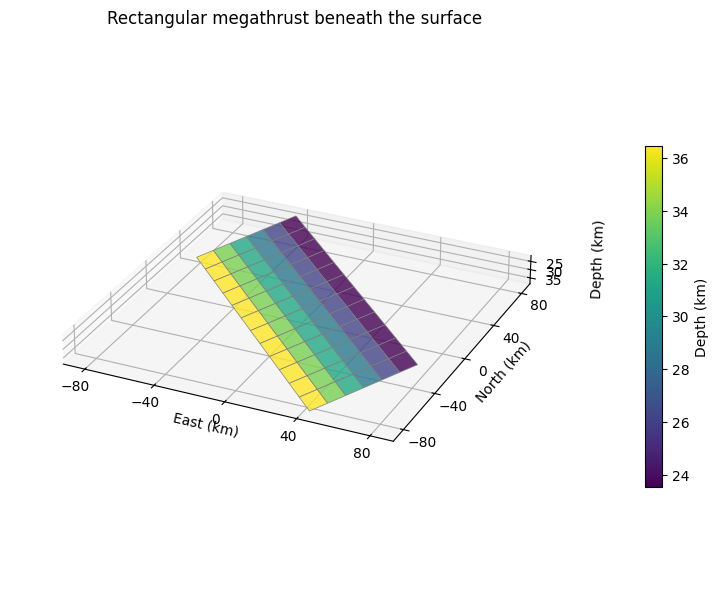

In [5]:
geodef.plot.fault3d(
    fault, color_by="depth", view=(28, -65),
    title="Rectangular megathrust beneath the surface",
);
plt.show()

The 3-D perspective can make distances look distorted. Read the labeled axes as
well as the picture. Try changing `view=(elevation, azimuth)` in the plotting
cell. That changes only the camera, not the fault or its predictions.

## 7. Put slip on the fault

Slip lies within the fault plane. **Strike slip** is parallel to strike;
**dip slip** is parallel to the down-dip direction. A positive dip-slip value in
GeoDef represents reverse, or thrust, motion under the convention used here.

We will create a smooth patch of dip slip near the center. The formula below is
a two-dimensional bell-shaped curve. Its exact form is not geologically special;
it simply avoids an abrupt jump from slipping to nonslipping patches.

In [6]:
along_index = np.arange(fault.n_patches) % n_length
down_index = np.arange(fault.n_patches) // n_length
center_along = (n_length - 1) / 2
center_down = (n_width - 1) / 2

In [7]:
slip_dip = 3 * np.exp(
    -((along_index - center_along) / 3) ** 2
    -((down_index - center_down) / 1.5) ** 2
)
slip_strike = np.zeros(fault.n_patches)

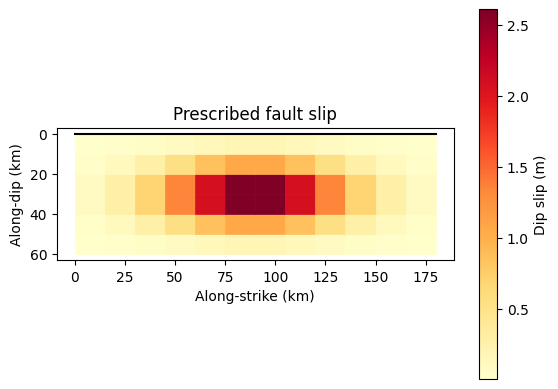

In [8]:
geodef.plot.slip(
    fault, slip_dip, cmap="YlOrRd", updip_edge=True,
    colorbar_label="Dip slip (m)", title="Prescribed fault slip",
);
plt.show()

## 8. Moment and magnitude: how large is the source?

Before looking at surface motion, we can measure the physical size of the fault
source. The scalar seismic moment is

$$
M_0 = \mu\sum_k A_k s_k,
$$

where $\mu$ is shear modulus, $A_k$ is patch area, and $s_k$ is slip magnitude.
The sum is an area-weighted measure of slip across the entire fault. GeoDef's
default shear modulus is 30 GPa, a typical crustal value rather than a measured
property of this synthetic location.

In [9]:
moment = fault.moment(slip_dip)
magnitude = fault.magnitude(slip_dip)
print(f"seismic moment: {moment:.2e} N m")
print(f"moment magnitude: Mw {magnitude:.2f}")

seismic moment: 1.89e+20 N m
moment magnitude: Mw 7.45


Moment magnitude compresses the very large range of earthquake moments onto a
logarithmic scale:

$$
M_w = \frac{2}{3}\log_{10}(M_0)-6.07,
$$

when $M_0$ is in newton meters. Doubling every slip value doubles moment, but it
increases magnitude by only about 0.20. Magnitude is therefore not linear in
slip even though moment and elastic displacement are.

## 9. Build a surface calculation grid

We next calculate displacement across a square region centered on the fault.
The grid coordinates are local East and North distances in kilometers. GeoDef's
fault method accepts geographic latitude and longitude, so the explicit local
frame converts our regular grid to geographic coordinates.

In [10]:
surface_axis_km = np.linspace(-220, 220, 81)
surface_east_km, surface_north_km = np.meshgrid(
    surface_axis_km, surface_axis_km
)

In [11]:
surface_geo = fault.frame.to_geographic(
    east=surface_east_km * 1000,
    north=surface_north_km * 1000,
    up=np.zeros_like(surface_east_km),
)

`surface_geo[..., 0]` is longitude and `surface_geo[..., 1]` is latitude.
Flattening them gives GeoDef one long list of surface points. After the forward
calculation, we reshape each answer back to the 81 by 81 grid so it can be
displayed as a map.

In [12]:
field_e, field_n, field_u = fault.displacement(
    surface_geo[..., 1].ravel(), surface_geo[..., 0].ravel(),
    slip_strike=slip_strike, slip_dip=slip_dip,
)

In [13]:
grid_shape = surface_east_km.shape
field_e = field_e.reshape(grid_shape)
field_n = field_n.reshape(grid_shape)
field_u = field_u.reshape(grid_shape)

## 10. Map the East, North, and Up components

A displacement vector has three components. The first map shows motion toward
the east as positive, the second shows motion toward the north as positive, and
the third shows upward motion as positive. Red and blue indicate opposite signs;
zero displacement lies at the center of the shared color scale.

All three panels use the same color limits. This makes their amplitudes directly
comparable, although it causes the smaller North component to look less vivid.

In [14]:
component_fields = (field_e, field_n, field_u)
component_names = ("East", "North", "Up")
color_limit = max(np.max(np.abs(values)) for values in component_fields)
extent = [surface_axis_km[0], surface_axis_km[-1]] * 2

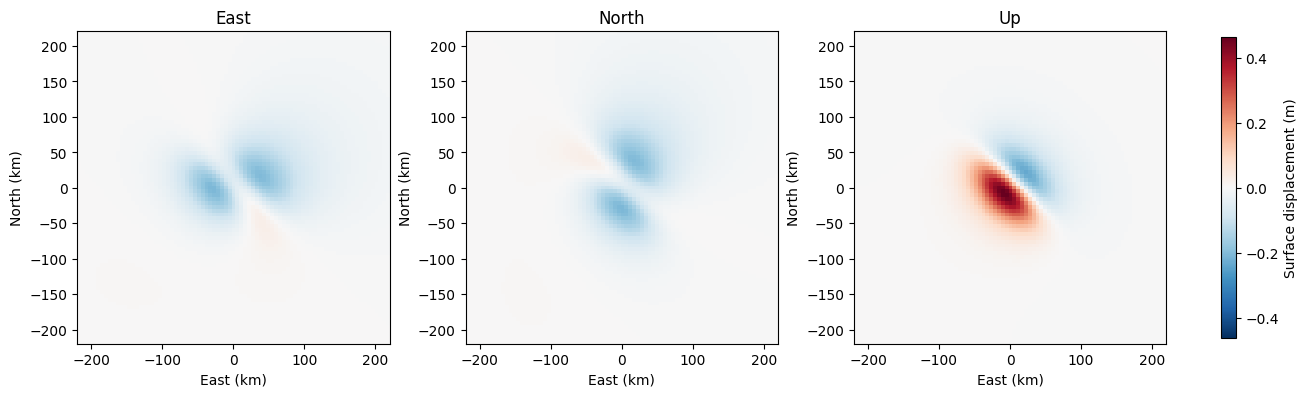

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
for ax, values, name in zip(axes, component_fields, component_names):
    image = ax.imshow(values, origin="lower", extent=extent,
                      cmap="RdBu_r", vmin=-color_limit, vmax=color_limit)
    ax.set(title=name, xlabel="East (km)", ylabel="North (km)")
fig.colorbar(image, ax=axes, label="Surface displacement (m)", shrink=0.8);
plt.show()

The field is smooth even though slip is represented on separate patches. The
elastic response spreads and overlaps as it travels from depth to the surface.
Positive and negative lobes are not extra faults; they are different parts of
the vector response to the same buried slip.

Change `strike` by 45 degrees and rerun the notebook. The component maps should
rotate and exchange some East/North amplitude, while moment magnitude remains
unchanged because area and slip did not change.

## 11. Read two profiles through the displacement field

A map can hide the detailed shape of a signal. A **profile** is a line through
the map plotted as displacement versus distance. We take an east–west line and
a north–south line through the center of the calculation grid.

In [16]:
center = surface_axis_km.size // 2
east_west = [values[center, :] for values in component_fields]
north_south = [values[:, center] for values in component_fields]
profile_sets = (east_west, north_south)
profile_titles = ("East–west profile", "North–south profile")
profile_xlabels = ("East (km)", "North (km)")

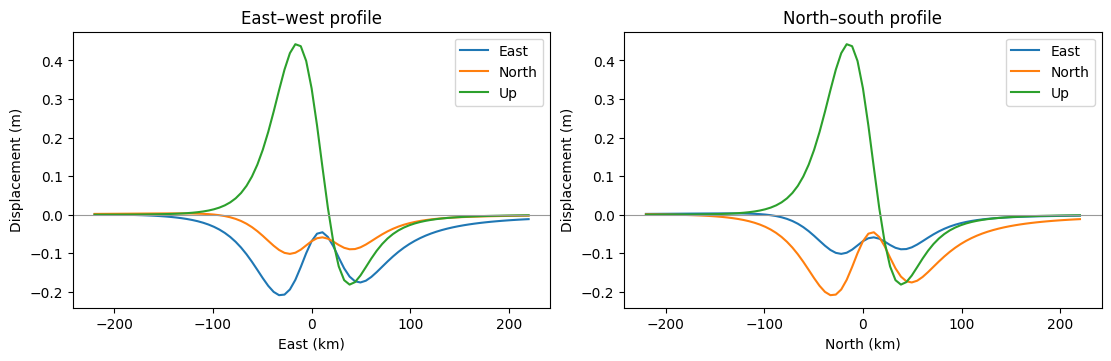

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), constrained_layout=True)
for ax, profiles, title, xlabel in zip(
    axes, profile_sets, profile_titles, profile_xlabels
):
    for values, name in zip(profiles, component_names):
        ax.plot(surface_axis_km, values, label=name)
    ax.set(title=title, xlabel=xlabel, ylabel="Displacement (m)")
    ax.axhline(0, color="0.6", linewidth=0.8)
    ax.legend()
plt.show()

Profiles make wavelength and sign changes easier to see. A deeper fault usually
produces a broader, lower-amplitude profile. A shallower fault produces a
narrower pattern with stronger gradients. Test that prediction by changing only
`depth` in the fault-definition cell.

## 12. View the prediction as a GNSS network

Real GNSS stations are sparse points, not a continuous image. We sample every
tenth row and column of the surface grid and place the predictions in a GeoDef
`GNSS` dataset. Horizontal motion will appear as arrows; vertical motion will
appear as colored dots.

In [18]:
sample = np.s_[::10, ::10]
station_geo = surface_geo[sample]
station_e = field_e[sample]
station_n = field_n[sample]
station_u = field_u[sample]

In [19]:
gnss = geodef.data.gnss(
    lon=station_geo[..., 0].ravel(), lat=station_geo[..., 1].ravel(),
    east=station_e.ravel(), north=station_n.ravel(), up=station_u.ravel(),
    sigma_east=0.002, sigma_north=0.002, sigma_up=0.005,
    name="synthetic_forward_prediction",
)

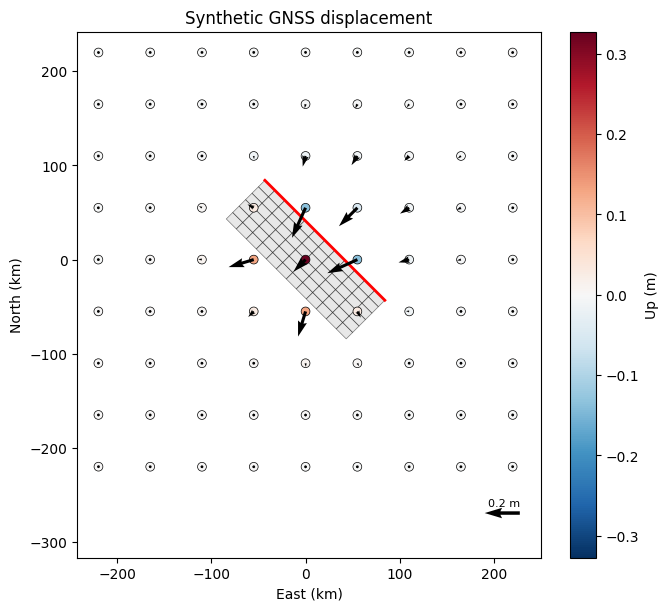

In [20]:
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
geodef.plot.map_view(fault, ax=ax, show_trace=True)
arrow_scale = 35 / np.hypot(station_e, station_n).max()
geodef.plot.vectors(
    gnss, fault, ax=ax, components="both", scale=arrow_scale,
    ellipses=False, legend=True, scale_arrow=0.2,
    scale_arrow_label="0.2 m", vertical_colorbar_label="Up (m)",
    title="Synthetic GNSS displacement",
);
plt.show()

The fault polygons show the horizontal projection of the buried source. The
arrows encode two components at once, while dot color encodes the third. This is
a standard geodetic view because it preserves station locations and vector
directions, but the continuous component maps and profiles remain valuable for
understanding what lies between stations.

## 13. The same calculation as $\mathbf{d}=G\mathbf{m}$

GeoDef can expose the linear calculation directly. For fixed fault geometry,
each column of the Green's matrix $G$ is the surface response to one meter of
slip on one patch. The model vector $\mathbf{m}$ contains all strike-slip values
followed by all dip-slip values. Multiplication adds the scaled patch responses:

$$
\mathbf{d}=G\mathbf{m}.
$$

Chapter 02 examines this matrix carefully. Here we verify that it produces the
same sparse-station prediction already calculated by `fault.displacement`.

In [21]:
station_lat = station_geo[..., 1].ravel()
station_lon = station_geo[..., 0].ravel()
green_matrix = fault.greens_matrix(station_lat, station_lon)
slip_vector = np.concatenate([slip_strike, slip_dip])
matrix_prediction = green_matrix @ slip_vector

In [22]:
direct_prediction = np.column_stack([
    station_e.ravel(), station_n.ravel(), station_u.ravel()
]).ravel()
print("same prediction:", np.allclose(matrix_prediction, direct_prediction))

same prediction: True


Because the matrix multiplication is linear,

$$
G(\mathbf{m}_1+\mathbf{m}_2)=G\mathbf{m}_1+G\mathbf{m}_2.
$$

Doubling slip doubles every predicted displacement. Adding two slip models adds
their displacement fields exactly, as long as fault geometry and elastic
properties stay fixed. This principle is called **superposition**.

## 14. A guided parameter playground

Return to the `Fault.planar` and `slip_dip` cells. Change only one parameter,
restart the kernel, and run all cells. Before looking at the figures, write down
what you expect.

| Change | Question to ask |
|---|---|
| Increase `depth` | Does the pattern become broader, weaker, or both? |
| Increase `dip` | How does the balance between horizontal and vertical motion change? |
| Change `strike` | Do the three component maps rotate in the way you expected? |
| Increase `length` | Which direction of the pattern becomes longer? |
| Double `slip_dip` | What changes linearly? What changes logarithmically? |
| Set dip slip to zero and prescribe strike slip | Which lobes and profile signs change? |

If a result surprises you, restore the original value and confirm that the
original output returns. Then try a smaller change. This one-parameter-at-a-time
habit is useful far beyond this tutorial.

## Checkpoint questions

**Why does a rectangular Okada source reduce to four signed evaluations?**

<details><summary>Answer</summary>

The elemental response is integrated once along length and once along width.
Evaluating a two-dimensional antiderivative at both pairs of limits produces the
four rectangle corners with alternating signs.

</details>

**Does using more patches make the half-space assumptions more realistic?**

<details><summary>Answer</summary>

No. More patches allow slip to vary at finer spatial scales, but the material is
still flat, homogeneous, isotropic, and elastic.

</details>

**Why does doubling slip add about 0.20 rather than 2 to moment magnitude?**

<details><summary>Answer</summary>

Moment is linear in slip, but magnitude is proportional to the base-10 logarithm
of moment. The increase is $(2/3)\log_{10}(2)\approx0.20$.

</details>

## Common mistakes

- **Mixing kilometers and meters.** GeoDef geometry uses meters. A depth entered
  as `25` means 25 meters, not 25 kilometers.
- **Confusing center depth and top-edge depth.** `Fault.planar` uses the rectangle
  center. Dip and width determine the shallowest and deepest edges.
- **Treating a color map as fault slip.** The surface component maps show ground
  displacement, not slip at the surface.
- **Comparing colors with different limits.** Check each colorbar before deciding
  which component is larger.
- **Changing several parameters at once.** The result may change, but the cause
  becomes difficult to identify.

## Recap

- Okada begins with an elemental dislocation response in an elastic half-space
  and integrates it analytically across a rectangle.
- The finite-source formula can be evaluated through four signed corner terms.
- A multi-patch fault adds the response from many constant-slip rectangles.
- Moment combines rigidity, area, and slip; moment magnitude is logarithmic.
- East, North, and Up maps, profiles, and GNSS vectors reveal complementary
  aspects of the same forward prediction.
- With geometry fixed, displacement is a linear function of slip.

Chapter 02 will open the Green's matrix and examine what its rows, columns, and
conditioning mean.

## Exercises

Worked solutions are in `solutions/01_forward_model_solutions.ipynb`.

1. **Depth experiment.** Compare center depths of 20 km and 40 km. Before
   calculating, predict which source will have the larger peak displacement and
   which will have the broader profile.
2. **Dip experiment.** Compare dips of 15°, 35°, and 60°. Describe how the East,
   North, and Up fields change; do not report only one maximum value.
3. **Moment scaling.** Double every slip value. Verify the factors by which
   moment and peak displacement change, and calculate the change in magnitude.
4. **Different mechanism.** Set dip slip to zero and use the same bell-shaped
   values as strike slip. Plot all three surface components and describe the new
   symmetry.
5. **Superposition.** Split the original dip-slip model into two arrays whose sum
   equals the original. Predict each separately and verify that their summed
   displacement equals the original displacement.

## Further reading

- Okada, Y. (1985), “Surface deformation due to shear and tensile faults in a
  half-space,” *Bulletin of the Seismological Society of America*, 75(4),
  1135–1154. [doi:10.1785/BSSA0750041135](https://doi.org/10.1785/BSSA0750041135)
- Hanks, T. C., and Kanamori, H. (1979), “A moment magnitude scale,”
  *Journal of Geophysical Research*, 84(B5), 2348–2350.
- Segall, P. (2010), *Earthquake and Volcano Deformation*, Chapters 2–3.
- [GeoDef fault documentation](../docs/fault.md) for the complete constructor and
  forward-model interfaces.